In [1]:
%%capture
# 필요한 라이브러리 설치 (pandas, matplotlib, statsmodels, openpyxl, scikit-learn)
import sys
!{sys.executable} -m pip install pandas matplotlib statsmodels openpyxl scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 한글 깨짐을 방지하기 위해 '맑은 고딕' 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1 데이터 전처리

In [2]:
# 데이터 가져온 후 날짜를 파이썬이 읽을 수 있도록 index로 설정
df = pd.read_excel('FLM통합매출.xlsx')
df['날짜'] = pd.to_datetime(df['날짜'])
df.set_index('날짜', inplace=True)

# 엑셀 컬럼의 띄어쓰기 제거
df.columns = df.columns.str.strip()

# y를 종속변수인 총매출로 두고, 외생변수를 행사장, 프로모션, 공휴일로 지정
y = df['총매출']
exog = df[['행사장', '프로모션여부', '공휴일 여부']]

# 결측치 제거 후 깨끗하게 정리
data = pd.concat([y, exog], axis=1).dropna()
y_clean = data['총매출']
exog_clean = data[['행사장', '프로모션여부', '공휴일 여부']]

# 2 SARIMAX (1,1,1) + 외생변수 3개 (행사장, 프로모션, 공휴일)

In [3]:
# SARIMAX(1,1,1) + 외생변수 3개 (행사장, 프로모션, 공휴일)
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    y_clean,
    exog=exog_clean,
    order=(1, 1, 1))
model_fit = model.fit()

print(model_fit.summary())

C:\Users\USER\anaconda3\envs\DLclass\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\USER\anaconda3\envs\DLclass\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                    총매출   No. Observations:                  268
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -3975.254
Date:                Sun, 12 Apr 2026   AIC                           7962.507
Time:                        00:23:01   BIC                           7984.031
Sample:                             0   HQIC                          7971.153
                                - 268                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
행사장         1.249e+05    8.9e+04      1.403      0.161   -4.96e+04    2.99e+05
프로모션여부     -4.305e+04   1.49e+05     -0.290      0.772   -3.34e+05    2.48e+05
공휴일 여부      1.381e+06   9.54e+04     14.483      0.0

# SARIMAX(1,1,1) + 외생변수 3개 모형에서 행사장과 프로모션 여부는 통계적으로 유의하지 않았으며, 공휴일 여부만 유의한 것으로 확인

# 3 잔차 시계열 그래프

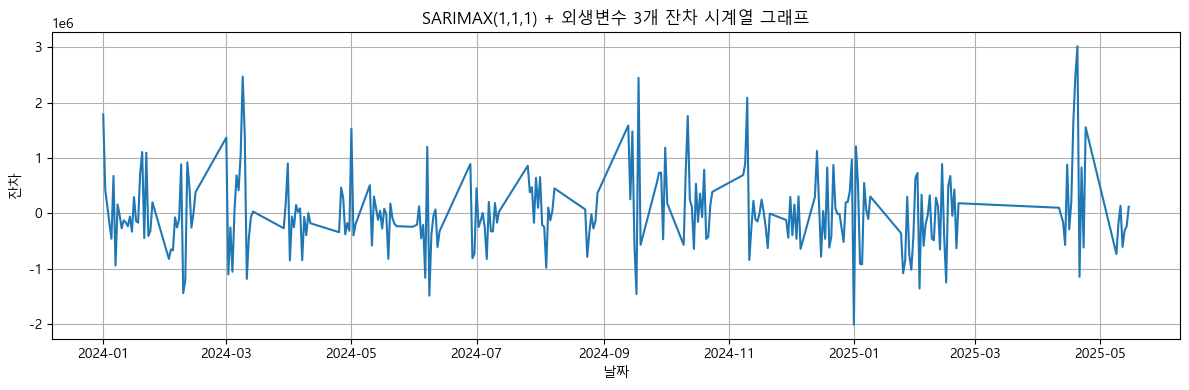

In [4]:
# 잔차 시계열 그래프
residuals = model_fit.resid

plt.figure(figsize=(12, 4))
plt.plot(residuals)
plt.title('SARIMAX(1,1,1) + 외생변수 3개 잔차 시계열 그래프')
plt.xlabel('날짜')
plt.ylabel('잔차')
plt.grid(True)
plt.tight_layout()
plt.show()

# SARIMAX(1,1,1) + 외생변수 3개를 시각적으로 잔차들을 확인한 결과, 잔차가 완전히 무작위라고 할 수는 없었지만 추세나 계절성이 관찰되지는 않았다.

# 4 잔차 포트만토 검정

In [5]:
# 잔차 포트만토 검정
from statsmodels.stats.diagnostic import acorr_ljungbox

# 결측치 제거 후 시간 간격 (lag) 설정
residuals_clean = model_fit.resid.dropna()
lags = [6, 12, 18, 24, 30, 36, 42, 48, 54, 60]

ljung_result = acorr_ljungbox(residuals_clean, lags=lags, return_df=True)
acf_vals = [residuals_clean.autocorr(lag=i) for i in lags]
ljung_result['Autocorrelation'] = acf_vals
ljung_result.index.name = 'Lag'

# 결과값을 소수점 4자리까지 출력
from IPython.display import display
display(ljung_result.round(4))

,lb_stat,lb_pvalue,Autocorrelation
Lag,,,
6,2.6118,0.8558,-0.0412
12,7.0532,0.8541,-0.0400
18,11.1916,0.8860,0.0805
24,13.6796,0.9536,0.0261
30,17.7359,0.9627,0.0944
36,24.0021,0.9370,-0.0037
42,26.1587,0.9736,-0.0666
48,32.7238,0.9549,0.0950
54,37.8780,0.9529,-0.0128


# 잔차의 p값이 통계적으로도 유의함을 확인

# 5 잔차의 ACF / PACF

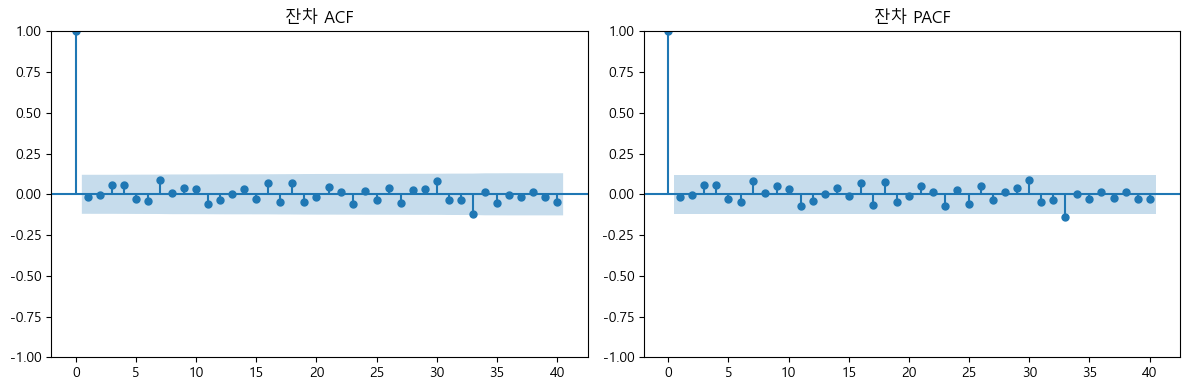

In [6]:
# 잔차 ACF / PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 각각 lag40까지의 ACF/PACF 결과값 그래프로 확인
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plot_acf(residuals_clean, ax=plt.gca(), lags=40)
plt.title('잔차 ACF')

plt.subplot(1, 2, 2)
plot_pacf(residuals_clean, ax=plt.gca(), lags=40)
plt.title('잔차 PACF')

plt.tight_layout()
plt.show()

# 잔차의 ACF / PACF가 파란 음영인 신뢰구간 안에 위치하고 있음을 확인

# 6 필루미네이트 AK수원점의 향후 1년 매출 예측

C:\Users\USER\anaconda3\envs\DLclass\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


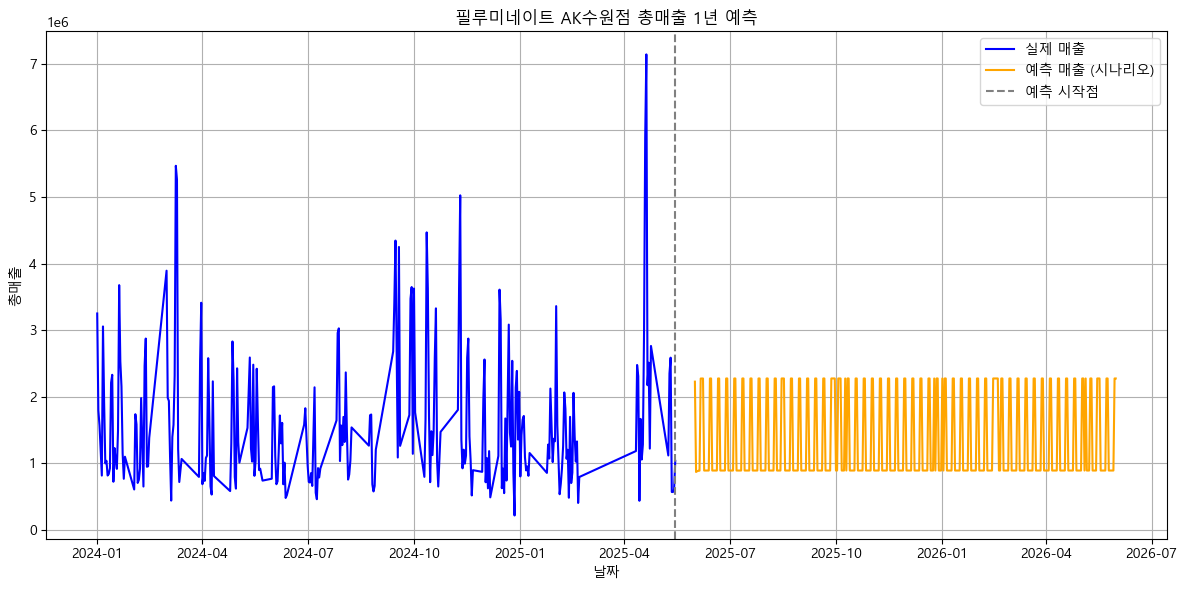

In [7]:
# 미래 외생변수를 불러온 후 날짜를 파이썬이 읽을 수 있도록 index로 설정
future_exog = pd.read_excel('my.xlsx')
future_exog['날짜'] = pd.to_datetime(future_exog['날짜'])
future_exog.set_index('날짜', inplace=True)
future_exog.columns = ['행사장', '프로모션여부', '공휴일 여부']

# 결측치 0으로 채우기
future_exog = future_exog.fillna(0).astype(int)

# 1년 매출 예측
forecast = model_fit.predict(
    start=len(y_clean),
    end=len(y_clean)+len(future_exog)-1,
    exog=future_exog)
forecast.index = future_exog.index

# 실제 매출 + 1년 예측 매출 시각화
plt.figure(figsize=(12, 6))
plt.plot(y_clean, label='실제 매출', color='blue')
plt.plot(forecast, label='예측 매출 (시나리오)', color='orange')
plt.axvline(y_clean.index[-1], color='gray', linestyle='--', label='예측 시작점')
plt.title('필루미네이트 AK수원점 총매출 1년 예측')
plt.xlabel('날짜')
plt.ylabel('총매출')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 예측값은 일 평균 190만원으로 예측이 되었다. 유의했던 공휴일 여부만 반영하여 예측했을 때, 큰 이벤트나 프로모션 없이 공휴일 기준으로 예측하여 전체적으로 평균 190만원 수준에서 유지되게 예측이 되었다. 

# 7 예측값의 RMSE

In [8]:
# RMSE 계산
from sklearn.metrics import mean_squared_error

fitted_values = model_fit.fittedvalues
rmse = np.sqrt(mean_squared_error(y_clean[1:], fitted_values[1:]))
mean_val = y_clean.mean()

print(f'모델 학습 RMSE: {rmse:.0f}원')
print(f'실제 매출 평균: {mean_val:.0f}원')
print(f'평균 대비 오차율: {(rmse/mean_val)*100:.2f}%')

모델 학습 RMSE: 702951원
실제 매출 평균: 1580118원
평균 대비 오차율: 44.49%


# RMSE 기준 오차율이 44.49%로 높게 나왔는데, 필루미네이트의 매장 특성상 단기 프로모션, 이벤트 등 외생변수를 충분히 반영하지 못했다고 판단하였다.